**Name**: Abhi Mondal       
*Roll No*: 22MS075

In [77]:
# packages
import numpy as np
import matplotlib.pyplot as plt
from numba import njit              # used for fast compilation (for installation, run "pip install numba")
from scipy.optimize import curve_fit

In [67]:
@njit
# input: population size, w (parameter for finite population) ,pay off matrix, initial of C (in C vs D game)
# output (boolean type): 1 if C is fixed and 0 if D is fixed
def moran_fixation(N, w, payoff_matrix, initial_C):
    count_C = initial_C

    # initialize the population
    pop = np.ones(N,dtype=np.int32)
    pop[:count_C] = 0             # A -> 0 and B -> 1
    np.random.shuffle(pop)          # shuffle the population

    while count_C > 0 and count_C < N:
        count_D = N - count_C   # D numbers

        # Payoffs at current composition
        total_payoff_C = (payoff_matrix[0][0]*(count_C - 1) + payoff_matrix[0][1]*count_D) / (N - 1)    #F_i
        total_payoff_D = (payoff_matrix[1][0]*count_C + payoff_matrix[1][1]*(count_D - 1)) / (N - 1)    #G_i

        fitness_C = 1.0 - w + w * total_payoff_C    #f_i
        fitness_D = 1.0 - w + w * total_payoff_D    #g_i

        # Reproduction: proportional to fitness -> normalized
        total_fitness =  fitness_C +  fitness_D

        parent_idx = -1

        # selection for reproduction
        while parent_idx == -1:
            candidate = np.random.randint(0, N) # Pick a Random member
            
            # compare with normalized fitness for reproduction
            if pop[candidate] == 0 and np.random.random() < ( fitness_C / total_fitness) :
                parent_idx = candidate # C is selected for reproduce
            if pop[candidate] == 1 and np.random.random() < ( fitness_D / total_fitness ):
                parent_idx = candidate # D is selected for reproduce

        # selection for death
        death_idx = np.random.randint(0, N) 

        # exchange
        old_trait = pop[death_idx]
        new_trait = pop[parent_idx]

        pop[death_idx] = new_trait

        # tracking of frequencies
        if old_trait == 0 and new_trait == 1:
            count_C -= 1
        elif old_trait == 1 and new_trait == 0:
            count_C += 1

# final return which one fixed
    if count_C == N:
        return 1
    else:
        return 0

In [68]:
@njit
# input: population number, w, number of trials, payoff matrix
# output: probability of fixation of C
def fixation_probability(N,w,Nt,payoff_matrix):
    count_fix_C = 0
    # run for Nt trials
    for _ in range(Nt):
        x = moran_fixation(N = N, w = w, payoff_matrix= payoff_matrix, initial_C = 1)
        count_fix_C = count_fix_C + x
    
    return count_fix_C/Nt   # probability

In [69]:
# parameters
m = 10 # number of rounds 

# TFT-ALLD payoff matrix
a = 3; b = 0; c = 5; d = 1;

payoff_matrix = np.array([
    [m*a, b+ (m-1)*d],
    [c + (m-1)*d, m*d]
], dtype=np.float64)

# array of population size
N_values = np.array([100,200,300,400,600,800,1000])

# trials 
Nt = 5000

In [74]:
rho_values = np.zeros(len(N_values))

for i in range(len(N_values)):
    rho_values[i] = fixation_probability(N = N_values[i],w = 1,Nt=Nt,payoff_matrix=payoff_matrix)

N_rho_values = N_values * rho_values

In [75]:
print(rho_values)

[0.0418 0.0236 0.011  0.0048 0.0028 0.0014 0.001 ]


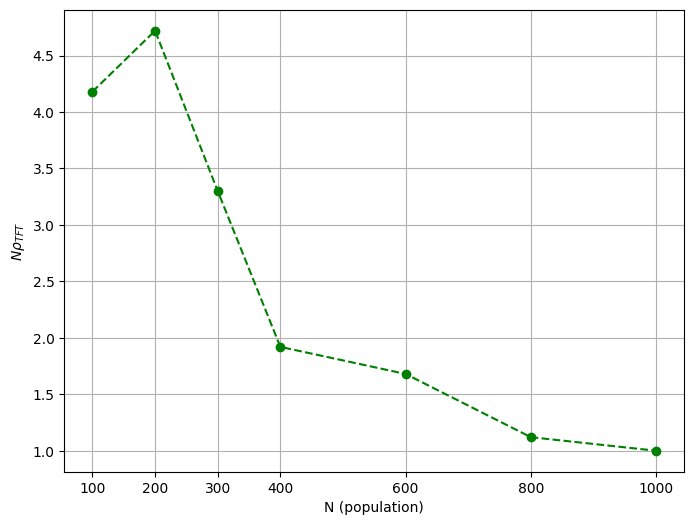

In [76]:
plt.figure(figsize= (8,6))
plt.plot(N_values,N_rho_values, marker = 'o', color = 'green', linestyle = "--")
plt.xlabel("N (population)")
plt.ylabel(r"$N\rho_{TFT}$")
plt.xticks([100, 200, 300, 400, 600, 800, 1000])
plt.grid(True)
plt.show()

Note that this graph is not correctly showing the trend. So I am going to take more points in the population to make the graph smooth.

In [71]:
part1 = np.arange(10, 301, 5)
part2 = np.arange(320, 1001, 10)
N_values_smooth = np.concatenate((part1, part2))

In [72]:
rho_values_smooth = np.zeros(len(N_values_smooth))

for i in range(len(N_values_smooth)):
    rho_values_smooth[i] = fixation_probability(N = N_values_smooth[i],w = 1,Nt=Nt,payoff_matrix=payoff_matrix)

N_rho_values_smooth = N_values_smooth * rho_values_smooth

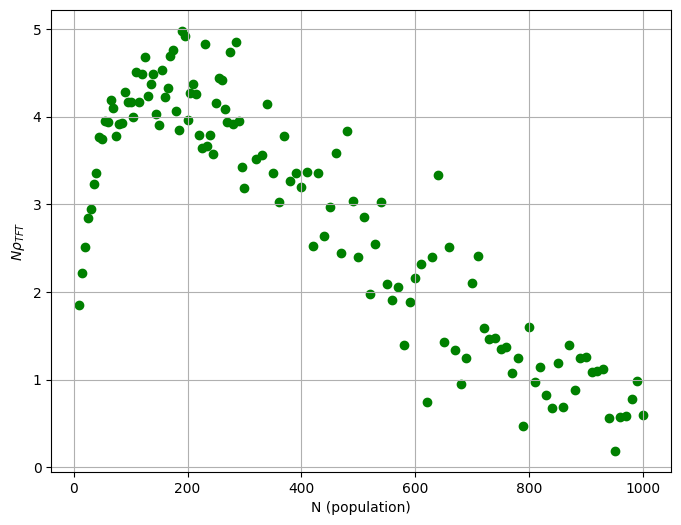

In [73]:
plt.figure(figsize= (8,6))
plt.scatter(N_values_smooth,N_rho_values_smooth, marker = 'o', color = 'green')
plt.xlabel("N (population)")
plt.ylabel(r"$N\rho_{TFT}$")
# plt.xticks([100, 200, 300, 400, 600, 800, 1000])
plt.grid(True)
plt.show()

This graph correctly depict the trend which is mentioned in the book by Nowak. Here I took more data points for population and plotted it. The peak is clear from this graph. Also every case I took the number of trials to be 5000 for better result.

In [78]:
# The function: a*N^b * exp(-c*N)
def fit_func(N, a, b, c):
    return a * (N**b) * np.exp(-c * N)

In [80]:
popt, _ = curve_fit(fit_func, N_values_smooth, N_rho_values_smooth, p0=[0.1, 0.5, 0.001])


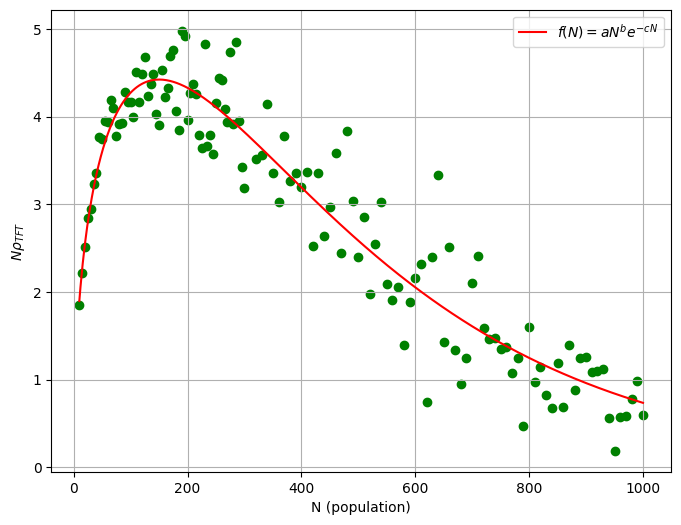

In [85]:
# Generate smooth points for plotting
N_smooth = np.linspace(10, 1000, 500)
y_fit = fit_func(N_smooth, *popt)

plt.figure(figsize= (8,6))
plt.scatter(N_values_smooth,N_rho_values_smooth, marker = 'o', color = 'green')
plt.xlabel("N (population)")
plt.ylabel(r"$N\rho_{TFT}$")
plt.plot(N_smooth, y_fit, color='red', label= r'$f(N) = a N^b e^{-cN}$')
plt.grid(True)
plt.legend(loc = "best")
plt.show()